# Contour Analysis

End-to-end analysis of annotated contour JSON files: loading, visualisation, and statistics at the segment, part and call level.

## 1. Setup

In [4]:
import importlib
import sys
from itertools import combinations
from pathlib import Path

import matplotlib.cm as cm
import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.manifold import TSNE

import process_contour
importlib.reload(process_contour)
from process_contour import *

## 2. Load Data

Load every annotated contour and build three tidy DataFrames:

| DataFrame | Granularity |
|-----------|-------------|
| `segs_df` | one row per segment |
| `parts_df` | one row per contour part |
| `calls_df` | one row per call |


In [5]:
all_contours = load_all_contours()
filename_to_clan = dict(zip(catalogue_df["filename"], catalogue_df["clan"]))

print(f"Loaded {len(all_contours)} contours")
catalogue_df[["filename", "call_type", "clan"]].head()

Skipping /Users/emmanuelfernandez/Documents/orca/orca-tokenizer/annotation_audacity/contour/../../annotations/N08i-A1-3_contour.json: skip
Skipping empty part P2 in /Users/emmanuelfernandez/Documents/orca/orca-tokenizer/annotation_audacity/contour/../../annotations/N09i-A1-2_contour.json
Skipping /Users/emmanuelfernandez/Documents/orca/orca-tokenizer/annotation_audacity/contour/../../annotations/N12-I1,I2,I18-3_contour.json: skip
Skipping /Users/emmanuelfernandez/Documents/orca/orca-tokenizer/annotation_audacity/contour/../../annotations/N30-G1-1_contour.json: SKIP
Skipping empty part P1 in /Users/emmanuelfernandez/Documents/orca/orca-tokenizer/annotation_audacity/contour/../../annotations/N44-G1-1_contour.json
Loaded 185 contours
Loaded 185 contours


,filename,call_type,clan
0,N01i-A1-1,N01i,A
1,N01i-A1-2,N01i,A
2,N01i-A1-3,N01i,A
3,N01i-A1-4,N01i,A
4,N01ii-B1-1,N01ii,A


In [6]:
# ── segments ─────────────────────────────────────────────────────────────────
seg_rows = []
for c in all_contours:
    clan = filename_to_clan.get(c["filename"], "unknown")
    for s in c["segments_2nd"]:
        seg_rows.append({**s, "filename": c["filename"], "clan": clan})

segs_df = pd.DataFrame(seg_rows)
segs_df["duration"] = segs_df["t_end"] - segs_df["t_start"]
segs_df["f_mean"] = segs_df["f_start"] + segs_df["delta_f"] / 2

print(f"Segments: {len(segs_df)}")
segs_df.head()

Segments: 732


,t_start,t_end,f_start,f_end,delta_f,delta_t,slope,abs_delta_f,label,part_label,part_type,filename,clan,sub_segments,duration,f_mean
0,0.301988,0.439852,NaN,NaN,NaN,0.137864,NaN,NaN,too tight,P1,too tight,N01i-A1-1,A,NaN,0.137864,NaN
1,0.442503,0.508784,NaN,NaN,NaN,0.066281,NaN,NaN,gap,P2,gap,N01i-A1-1,A,NaN,0.066281,NaN
2,0.508784,0.765952,NaN,NaN,NaN,0.257168,NaN,NaN,PEAK,P3,precise,N01i-A1-1,A,"[{'t_start': 0.508784, 't_end': 0.601576, 'f_s...",0.257168,NaN
3,0.765952,1.505644,790.4359,843.1316,52.6957,0.739692,71.240057,52.6957,FLAT,P3,precise,N01i-A1-1,A,NaN,0.739692,816.78375
4,1.505644,1.700000,NaN,NaN,NaN,0.194356,NaN,NaN,PEAK,P3,precise,N01i-A1-1,A,"[{'t_start': 1.505644, 't_end': 1.635553, 'f_s...",0.194356,NaN


In [7]:
# ── parts ─────────────────────────────────────────────────────────────────────
parts_df = (
    segs_df
    .sort_values(["filename", "part_label", "t_start"])
    .groupby(["filename", "part_label"], sort=False)
    .agg(
        t_start=("t_start", "first"),
        t_end=("t_end", "last"),
        f_start=("f_start", "first"),
        f_end=("f_end", "last"),
        clan=("clan", "first"),
        part_type=("part_type", "first"),
        label=("label", lambda x: "_".join(x)),
        n_segments=("label", "size"),
    )
    .reset_index()
)
parts_df["delta_t"] = parts_df["t_end"] - parts_df["t_start"]
parts_df["delta_f"] = parts_df["f_end"] - parts_df["f_start"]
parts_df["f_mean"] = parts_df["f_start"] + parts_df["delta_f"] / 2
parts_df["f_mean_estimated"] = parts_df["f_mean"]
parts_df.loc[parts_df["label"] == "too tight", "f_mean_estimated"] = 100
parts_df.loc[parts_df["label"] == "blur", "f_mean_estimated"] = 50
parts_df.loc[parts_df["label"] == "vertical", "f_mean_estimated"] = 10

print(f"Parts: {len(parts_df)}")
parts_df.head()

Parts: 464


,filename,part_label,t_start,t_end,f_start,f_end,clan,part_type,label,n_segments,delta_t,delta_f,f_mean,f_mean_estimated
0,N01i-A1-1,P1,0.301988,0.439852,NaN,NaN,A,too tight,too tight,1,0.137864,NaN,NaN,100.00000
1,N01i-A1-1,P2,0.442503,0.508784,NaN,NaN,A,gap,gap,1,0.066281,NaN,NaN,NaN
2,N01i-A1-1,P3,0.508784,1.700000,790.4359,843.1316,A,precise,PEAK_FLAT_PEAK,3,1.191216,52.6957,816.78375,816.78375
3,N01i-A1-2,P1,0.190000,0.380000,NaN,NaN,A,too tight,too tight,1,0.190000,NaN,NaN,100.00000
4,N01i-A1-2,P2,0.392300,0.464625,803.6098,803.6098,A,precise,FLAT,1,0.072325,0.0000,803.60980,803.60980


In [8]:
# ── calls ─────────────────────────────────────────────────────────────────────
calls_df = (
    parts_df
    .sort_values(["filename", "part_label", "t_start"])
    .groupby("filename", sort=False)
    .agg(
        t_start=("t_start", "first"),
        t_end=("t_end", "last"),
        f_start=("f_start", "first"),
        f_end=("f_end", "last"),
        clan=("clan", "first"),
        label=("label", lambda x: "_".join(x)),
        n_parts=("label", "size"),
        n_segments=("n_segments", "sum"),
    )
    .reset_index()
)
calls_df["call_type_variant"] = calls_df["filename"].str.split("-", n=1).str[0]
calls_df["call_type"] = (
    calls_df["call_type_variant"]
    .str.replace(r"-\d+$", "", regex=True)
    .str.replace(r"[iv]", "", regex=True)
)

print(f"Calls: {len(calls_df)}")
calls_df.head()

Calls: 184


,filename,t_start,t_end,f_start,f_end,clan,label,n_parts,n_segments,call_type_variant,call_type
0,N01i-A1-1,0.301988,1.700000,790.4359,843.1316,A,too tight_gap_PEAK_FLAT_PEAK,3,5,N01i,N01
1,N01i-A1-2,0.190000,1.526248,803.6098,856.3056,A,too tight_FLAT_PEAK_FLAT_PEAK,3,5,N01i,N01
2,N01i-A1-3,0.384116,1.935679,210.7829,948.5231,A,FLAT_UP_PEAK_FLAT_UP,3,5,N01i,N01
3,N01i-A1-4,0.240000,1.644855,832.0498,799.2320,A,too tight_FLAT_PEAK_FLAT_PEAK,3,5,N01i,N01
4,N01ii-B1-1,0.242076,1.310233,698.4560,474.2615,A,too tight_gap_PEAK_FLAT_DOWN,3,5,N01ii,N01


## 3. Sample Call Visualisations

Plot a random selection of calls — spectrogram with overlaid contour and segment labels.

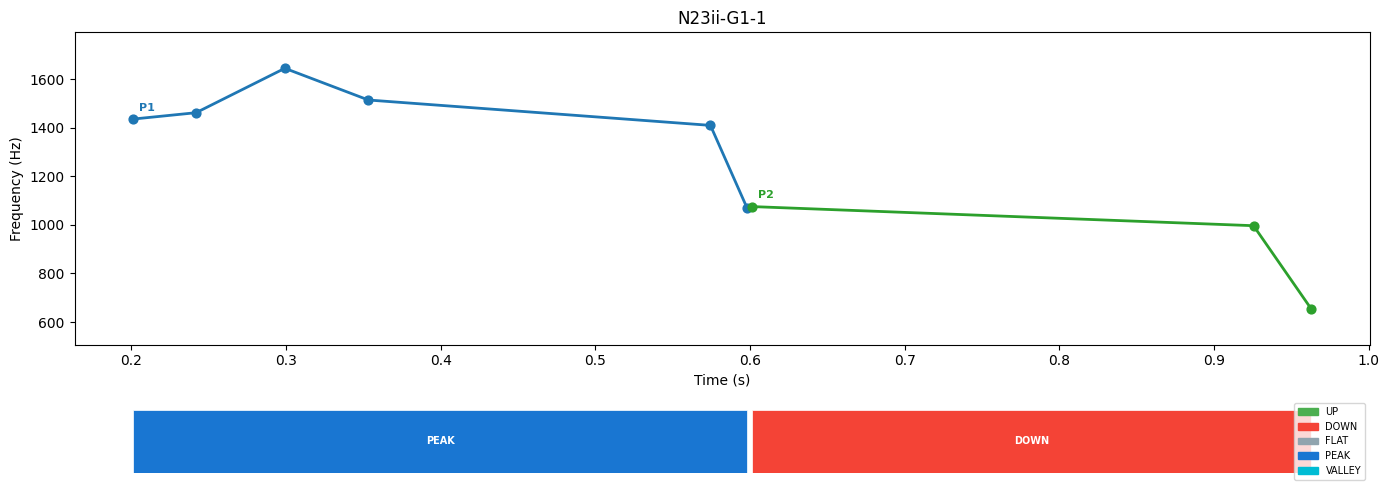

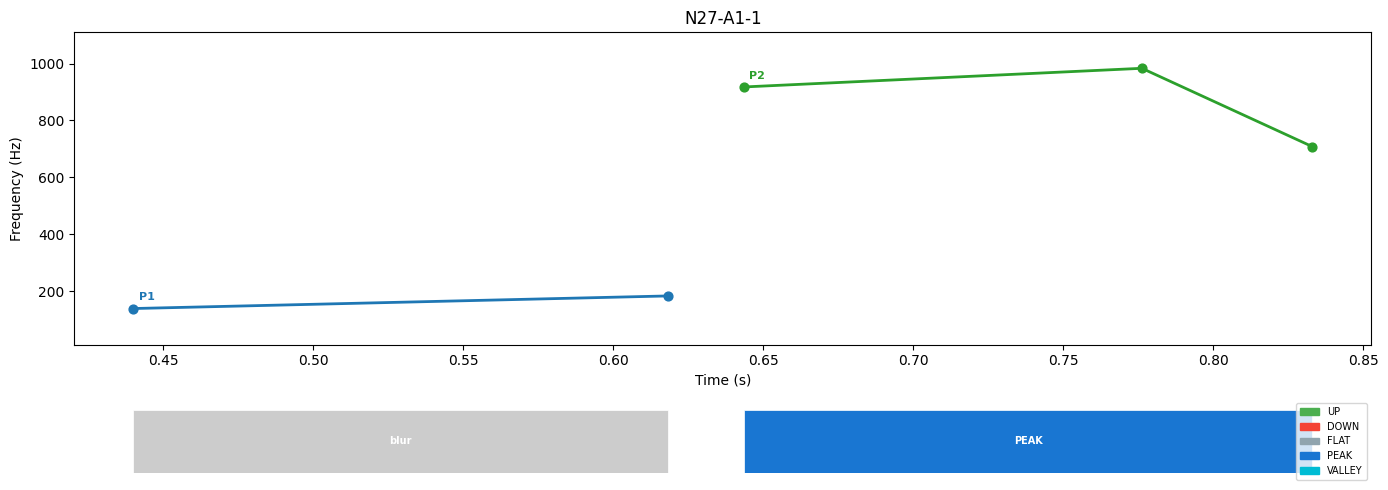

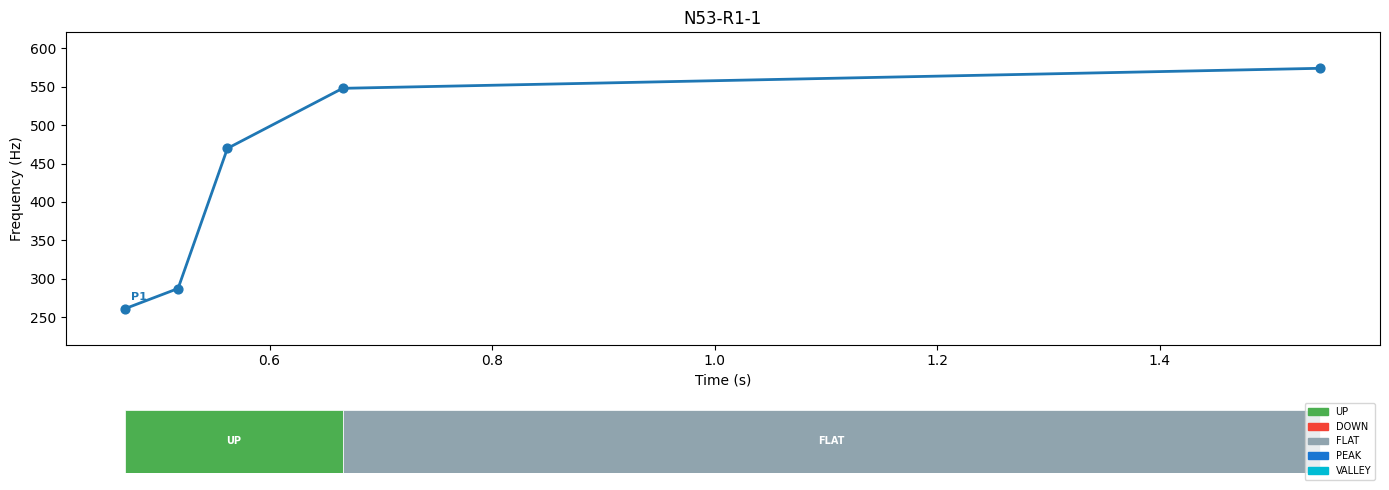

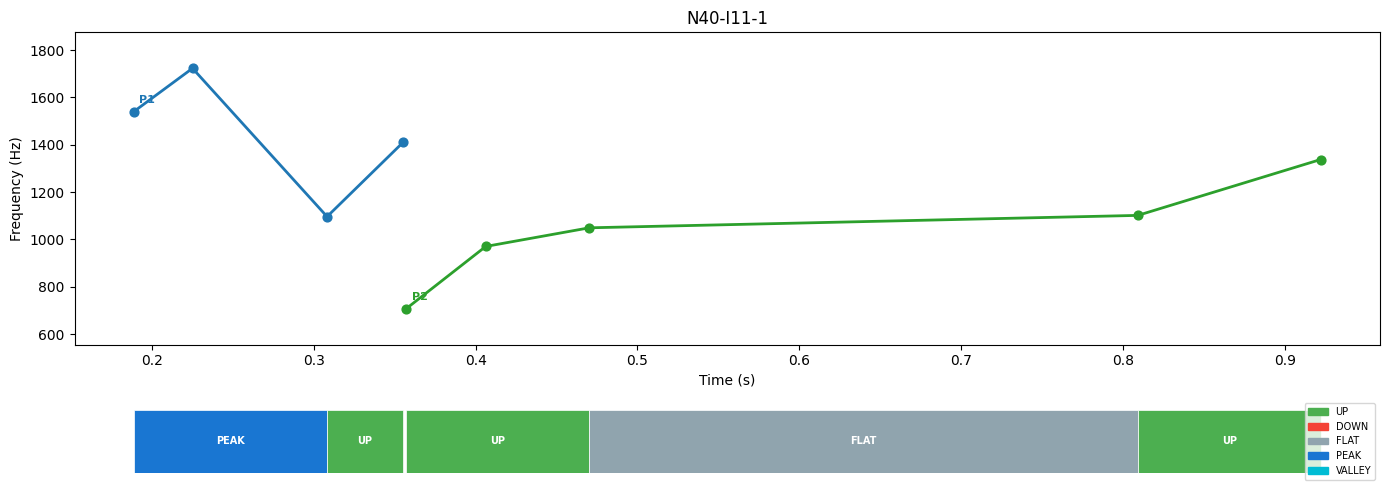

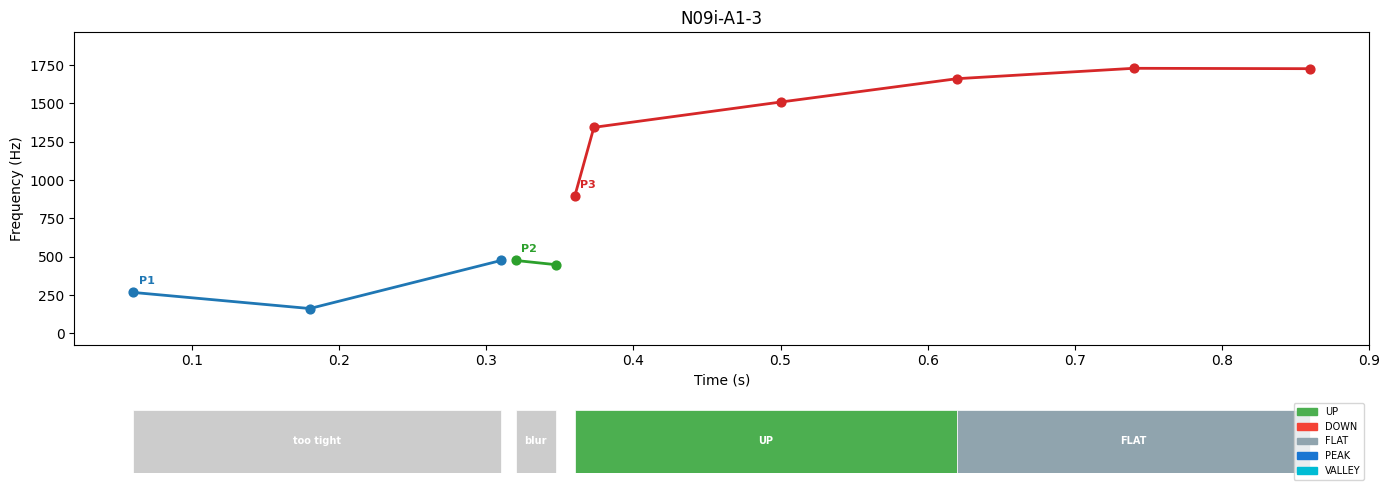

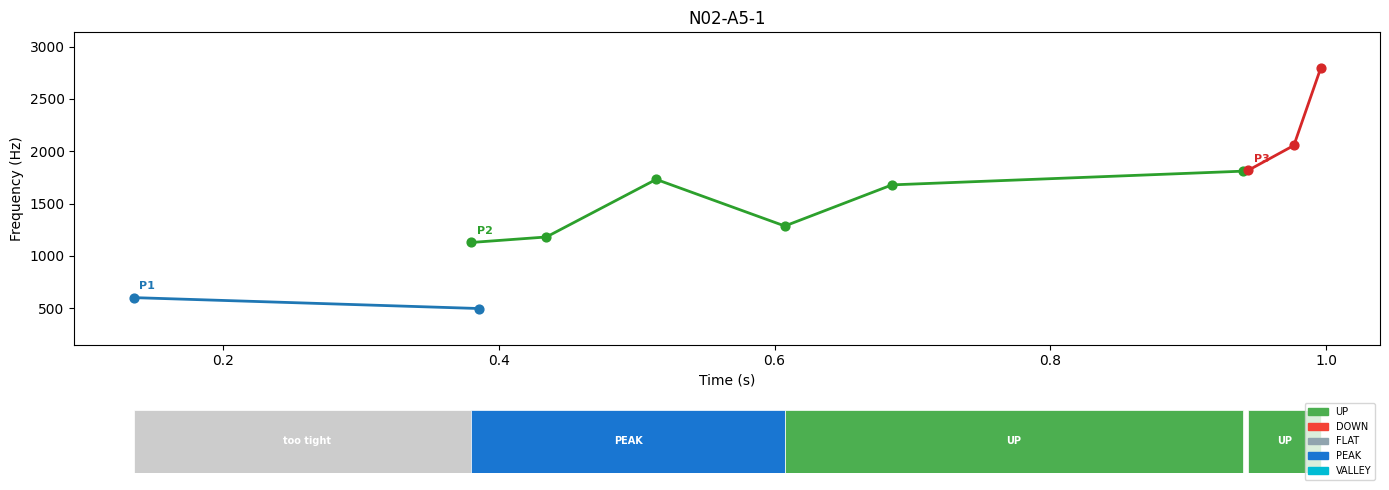

In [9]:
rng = np.random.default_rng(42)
sample_filenames = rng.choice(calls_df["filename"].values, size=min(6, len(calls_df)), replace=False)

for fn in sample_filenames:
    c = next(x for x in all_contours if x["filename"] == fn)
    plot_contour(c, with_spectrogram=False, segments=c["segments_3rd"], n_harmonics=1)

## 4. Segment Label Distribution

How often does each label (UP, DOWN, FLAT, PEAK, VALLEY, SQUIGGLE, …) appear, broken down by clan?

In [10]:
print(segs_df["label"].value_counts().to_string())

label
FLAT         241
UP           171
PEAK         104
DOWN          65
blur          59
too tight     37
VALLEY        35
vertical      14
gap            6


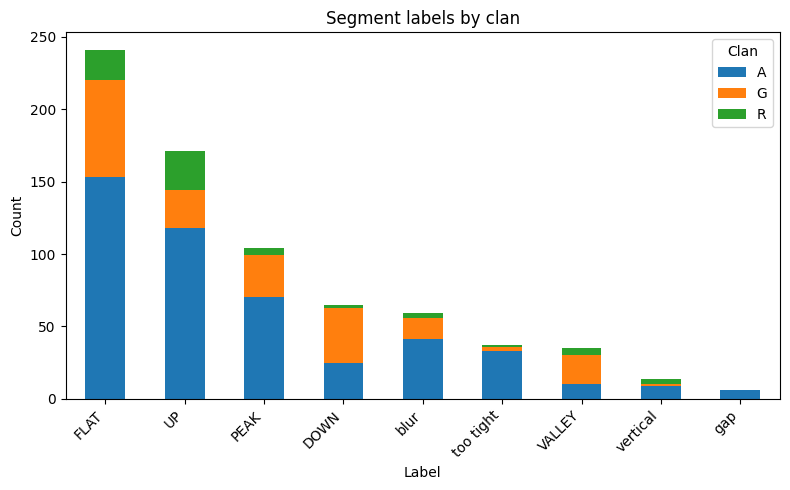

In [11]:
# Count plot by clan
ct_segs = segs_df.groupby(["label", "clan"]).size().unstack(fill_value=0)
ct_segs = ct_segs.loc[ct_segs.sum(axis=1).sort_values(ascending=False).index]

ct_segs.plot.bar(stacked=True, figsize=(max(len(ct_segs) * 0.5, 8), 5))
plt.ylabel("Count")
plt.xlabel("Label")
plt.title("Segment labels by clan")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Clan")
plt.tight_layout()
plt.show()

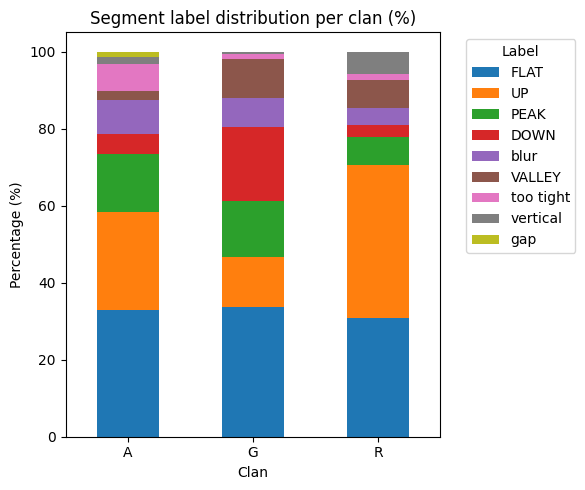

In [12]:
# Percentage breakdown per clan
ct_pct = segs_df.groupby(["clan", "label"]).size().unstack(fill_value=0)
ct_pct = ct_pct.div(ct_pct.sum(axis=1), axis=0) * 100
ct_pct = ct_pct[ct_pct.sum().sort_values(ascending=False).index]

ct_pct.plot.bar(stacked=True, figsize=(max(len(ct_pct) * 1.5, 6), 5))
plt.ylabel("Percentage (%)")
plt.xlabel("Clan")
plt.title("Segment label distribution per clan (%)")
plt.xticks(rotation=0)
plt.legend(title="Label", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 5. Segment Duration by Label

Violin plots show how long each label type typically lasts.

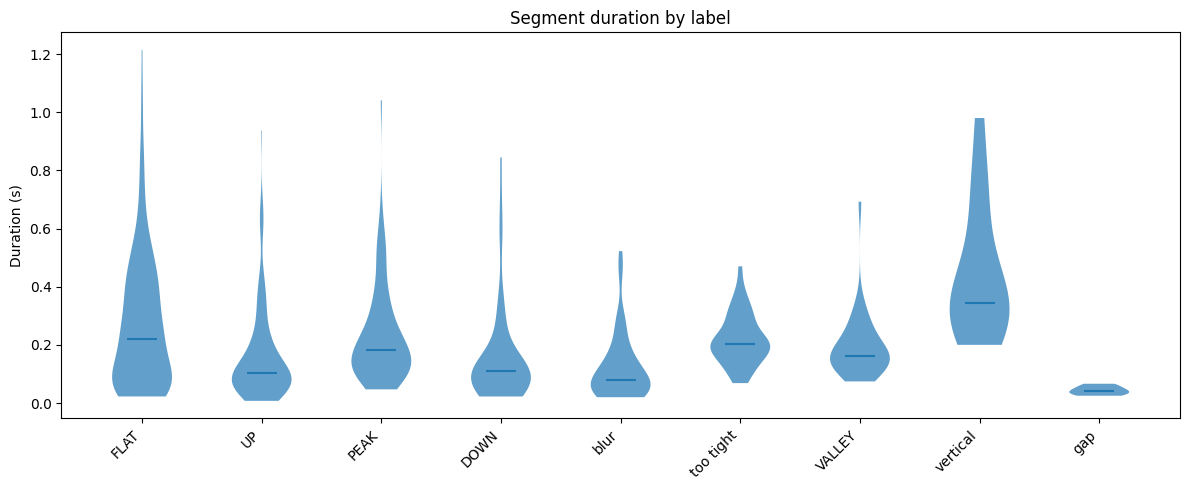

In [13]:
labels_ordered = segs_df["label"].value_counts().index.tolist()
data = [segs_df.loc[segs_df["label"] == lbl, "duration"].dropna().values for lbl in labels_ordered]

fig, ax = plt.subplots(figsize=(12, 5))
parts = ax.violinplot(data, positions=range(len(labels_ordered)), showmedians=True, showextrema=False)
for pc in parts["bodies"]:
    pc.set_alpha(0.7)

ax.set_xticks(range(len(labels_ordered)))
ax.set_xticklabels(labels_ordered, rotation=45, ha="right")
ax.set_ylabel("Duration (s)")
ax.set_title("Segment duration by label")
fig.tight_layout()
plt.show()

In [14]:
calls_df

,filename,t_start,t_end,f_start,f_end,clan,label,n_parts,n_segments,call_type_variant,call_type
0,N01i-A1-1,0.301988,1.700000,790.4359,843.1316,A,too tight_gap_PEAK_FLAT_PEAK,3,5,N01i,N01
1,N01i-A1-2,0.190000,1.526248,803.6098,856.3056,A,too tight_FLAT_PEAK_FLAT_PEAK,3,5,N01i,N01
2,N01i-A1-3,0.384116,1.935679,210.7829,948.5231,A,FLAT_UP_PEAK_FLAT_UP,3,5,N01i,N01
3,N01i-A1-4,0.240000,1.644855,832.0498,799.2320,A,too tight_FLAT_PEAK_FLAT_PEAK,3,5,N01i,N01
4,N01ii-B1-1,0.242076,1.310233,698.4560,474.2615,A,too tight_gap_PEAK_FLAT_DOWN,3,5,N01ii,N01
...,...,...,...,...,...,...,...,...,...,...,...
179,N51-R1-1,0.498255,1.990000,182.6887,957.1060,R,FLAT_UP_FLAT_UP,1,4,N51,N51
180,N51-R1-2,0.167185,0.763957,104.3935,1226.6239,R,FLAT_UP,1,2,N51,N51
181,N52-R1-1,0.033584,1.104456,314.6703,1080.2624,R,vertical_FLAT_PEAK_UP_FLAT_UP,3,6,N52,N52
182,N53-R1-1,0.470396,1.544193,260.9838,574.1644,R,UP_FLAT,1,2,N53,N53


## N parts per call/ N segments per part

In [15]:
calls_df["n_segments"].value_counts(normalize=True)

n_segments
3     0.260870
4     0.222826
5     0.206522
2     0.141304
6     0.081522
7     0.038043
1     0.027174
8     0.010870
13    0.005435
9     0.005435
Name: proportion, dtype: float64

In [16]:
n_parts_counts = calls_df["n_parts"].value_counts().sort_index()

# keep 1..4 as-is, and collapse everything >4 into a single "5+" bucket
n_parts_counts_grouped = n_parts_counts[n_parts_counts.index <= 4].copy()
n_parts_counts_grouped["5+"] = n_parts_counts[n_parts_counts.index > 4].sum()

n_parts_pct = n_parts_counts_grouped / n_parts_counts_grouped.sum() * 100
n_parts_pct

n_parts
1     12.500000
2     39.673913
3     32.608696
4     13.586957
5+     1.630435
Name: count, dtype: float64

In [17]:
n_seg_counts = parts_df["n_segments"].value_counts().sort_index()

# keep 1..4 as-is, and collapse everything >4 into a single "5+" bucket
n_seg_counts_grouped = n_seg_counts[n_seg_counts.index <= 4].copy()
n_seg_counts_grouped["5+"] = n_seg_counts[n_seg_counts.index > 4].sum()

n_seg_pct = n_seg_counts_grouped / n_seg_counts_grouped.sum() * 100
n_seg_pct

n_segments
1     62.284483
2     24.568966
3      9.482759
4      2.586207
5+     1.077586
Name: count, dtype: float64

## 6. Part-Level Label Combinations



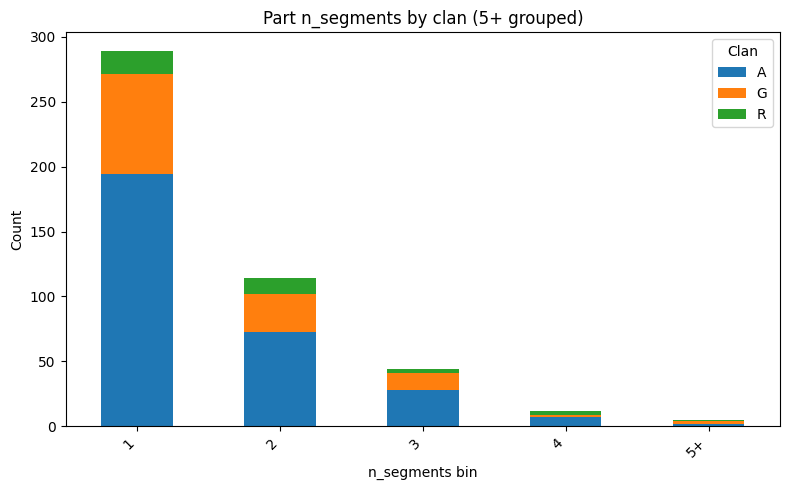

In [18]:
# Bin n_segments into 1..4 and "5+"
df = parts_df.copy()
df["n_seg_bin"] = df["n_segments"].where(df["n_segments"] <= 4, "5+")

# Counts per bin, split by clan
ct = df.groupby(["n_seg_bin", "clan"]).size().unstack(fill_value=0)

# Force x-axis order: 1,2,3,4,5+
bin_order = ["1", "2", "3", "4", "5+"]
ct.index = ct.index.map(str)
ct = ct.loc[bin_order]

# (Optional) reorder bins by total counts
# ct = ct.loc[ct.sum(axis=1).sort_values(ascending=False).index]

ct.plot.bar(stacked=True, figsize=(max(len(ct) * 0.5, 8), 5))
plt.ylabel("Count")
plt.xlabel("n_segments bin")
plt.title("Part n_segments by clan (5+ grouped)")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Clan")
plt.tight_layout()
plt.show()

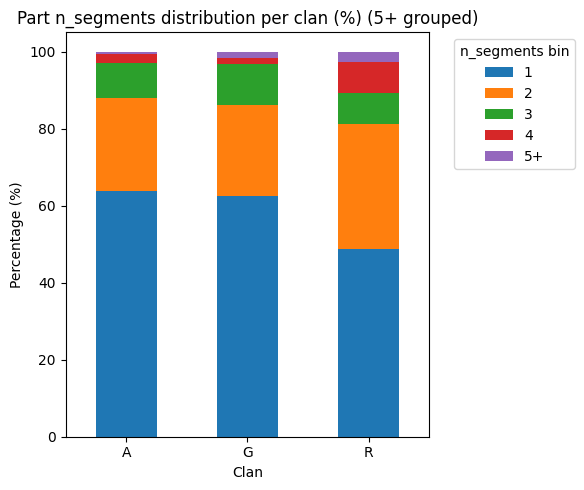

In [19]:
df = parts_df.copy()
df["n_seg_bin"] = df["n_segments"].where(df["n_segments"] <= 4, "5+")

# counts -> percent per clan
ct_counts = df.groupby("clan").size()
ct_pct = df.groupby(["clan", "n_seg_bin"]).size().unstack(fill_value=0)
ct_pct = ct_pct.div(ct_pct.sum(axis=1), axis=0) * 100

# reorder clans (rows) by total number of parts
ct_pct = ct_pct.loc[ct_counts.sort_values(ascending=False).index]

# enforce bin column order (and string-ify in case)
bin_order = ["1", "2", "3", "4", "5+"]
ct_pct.columns = ct_pct.columns.map(str)
ct_pct = ct_pct.reindex(columns=bin_order, fill_value=0)

ct_pct.plot.bar(stacked=True, figsize=(max(len(ct_pct) * 1.5, 6), 5))
plt.ylabel("Percentage (%)")
plt.xlabel("Clan")
plt.title("Part n_segments distribution per clan (%) (5+ grouped)")
plt.xticks(rotation=0)
plt.legend(title="n_segments bin", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [20]:
df["clan"]

0      A
1      A
2      A
3      A
4      A
      ..
459    R
460    R
461    R
462    R
463    R
Name: clan, Length: 464, dtype: object

In [22]:
from itertools import product


def generate_sequences(keywords, max_len=4, forbidden_pairs=None):
    """
    Generate all sequences of length 1..max_len from `keywords`,
    excluding sequences that contain any forbidden adjacent pair.

    Parameters
    ----------
    keywords        : list of str — the token vocabulary.
    max_len         : int — maximum sequence length (generates lengths 1 through max_len).
    forbidden_pairs : set of tuple[str, str] — pairs (a, b) that must not appear
                      side by side (order matters). Pass both (a,b) and (b,a) to
                      forbid in either direction.

    Returns
    -------
    list of tuple — all valid sequences.
    """
    if forbidden_pairs is None:
        forbidden_pairs = set()

    def is_valid(seq):
        for a, b in zip(seq, seq[1:]):
            if (a, b) in forbidden_pairs:
                return False
        return True

    results = []
    for length in range(1, max_len + 1):
        for seq in product(keywords, repeat=length):
            if is_valid(seq):
                results.append(seq)
    return results

keywords = ["UP", "DOWN", "FLAT", "PEAK", "VALLEY"]
forbidden = {("UP", "UP"), ("DOWN", "DOWN"), ("FLAT", "FLAT"), ("UP", "DOWN"), ("DOWN", "UP")}
seqs = generate_sequences(keywords, max_len=4, forbidden_pairs=forbidden)
print(f"{len(seqs)} valid sequences")
print(seqs[:10])


457 valid sequences
[('UP',), ('DOWN',), ('FLAT',), ('PEAK',), ('VALLEY',), ('UP', 'FLAT'), ('UP', 'PEAK'), ('UP', 'VALLEY'), ('DOWN', 'FLAT'), ('DOWN', 'PEAK')]


In [58]:
def combinations_with_replacement_count(n, r):
    """
    Compute the number of combinations with n distinct elements
    taken r at a time (with replacement, i.e., repetitions allowed).
    This is also known as n multichoose r: C(n + r - 1, r)
    """
    from math import comb
    return comb(n + r - 1, r)

# Example:
# Number of ways to choose 4 elements from 5 types, allowing repeats:
print(combinations_with_replacement_count(40, 4))  # returns 70
print(combinations_with_replacement_count(457, 4))  # returns 70
print(calls_df["call_type_variant"].nunique())

123410
1841369535
61


At the part level (precise parts only), how many distinct segment-sequence combinations are there per clan?

In [24]:
p_df = parts_df[(parts_df["part_type"] == "precise") & (parts_df["n_segments"] <= 4)].copy()

print(f"Parts (precise, ≤4 segs): {len(p_df)}")
print(f"  Distinct combinations (all):  {p_df['label'].nunique()}")
for clan in sorted(p_df["clan"].unique()):
    print(f"  Distinct combinations (Clan {clan}): {p_df[p_df['clan'] == clan]['label'].nunique()}")

# Overlap analysis across clans (based on distinct `label` combinations)
clans = sorted(p_df["clan"].unique())
clan_to_labels = {
    clan: set(p_df.loc[p_df["clan"] == clan, "label"].unique())
    for clan in clans
}

if len(clans) == 3:
    c1, c2, c3 = clans

    shared_all = clan_to_labels[c1] & clan_to_labels[c2] & clan_to_labels[c3]

    # Labels shared by exactly this pair (i.e., not present in the 3rd clan)
    shared_12 = (clan_to_labels[c1] & clan_to_labels[c2]) - clan_to_labels[c3]
    shared_13 = (clan_to_labels[c1] & clan_to_labels[c3]) - clan_to_labels[c2]
    shared_23 = (clan_to_labels[c2] & clan_to_labels[c3]) - clan_to_labels[c1]

    unique_1 = clan_to_labels[c1] - (clan_to_labels[c2] | clan_to_labels[c3])
    unique_2 = clan_to_labels[c2] - (clan_to_labels[c1] | clan_to_labels[c3])
    unique_3 = clan_to_labels[c3] - (clan_to_labels[c1] | clan_to_labels[c2])

    print(f" \n\n Shared by all three clans: {len(shared_all)}")
    print(shared_all)
    print(f"  Shared by Clan {c1} & {c2} only: {len(shared_12)}")
    print(shared_12)
    print(f"  Shared by Clan {c1} & {c3} only: {len(shared_13)}")
    print(f"  Shared by Clan {c2} & {c3} only: {len(shared_23)}")
    print(f"  Unique to Clan {c1}: {len(unique_1)}")
    print(f"  Unique to Clan {c2}: {len(unique_2)}")
    print(f"  Unique to Clan {c3}: {len(unique_3)}")
else:
    print(f"  (Clan overlap breakdown expects 3 clans; found {len(clans)}.)")

Parts (precise, ≤4 segs): 343
  Distinct combinations (all):  40
  Distinct combinations (Clan A): 27
  Distinct combinations (Clan G): 26
  Distinct combinations (Clan R): 12
 

 Shared by all three clans: 7
{'VALLEY', 'PEAK', 'UP', 'UP_FLAT', 'FLAT_UP', 'FLAT', 'UP_FLAT_UP'}
  Shared by Clan A & G only: 11
{'DOWN_FLAT_DOWN', 'PEAK_FLAT', 'FLAT_DOWN', 'PEAK_FLAT_DOWN', 'PEAK_PEAK', 'VALLEY_FLAT', 'PEAK_UP', 'UP_FLAT_DOWN_FLAT', 'DOWN', 'DOWN_FLAT', 'PEAK_FLAT_UP'}
  Shared by Clan A & R only: 0
  Shared by Clan G & R only: 0
  Unique to Clan A: 9
  Unique to Clan G: 8
  Unique to Clan R: 5


<Figure size 800x400 with 0 Axes>

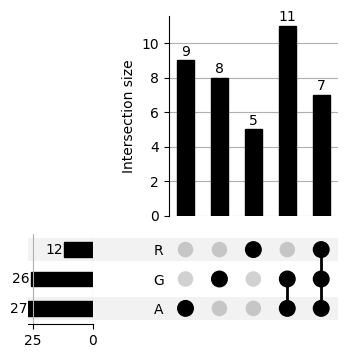

In [37]:
import warnings
from upsetplot import from_memberships, UpSet

warnings.filterwarnings("ignore", category=FutureWarning, module="upsetplot")

# Build membership list INCLUDING empty combinations to force them onto the plot
from itertools import combinations

all_clans = [c1, c2, c3]

# Map each subset to its count
subset_counts = {
    (c1, c2, c3): len(shared_all),
    (c1, c2):     len(shared_12),
    (c1, c3):     len(shared_13),
    (c2, c3):     len(shared_23),
    (c1,):        len(unique_1),
    (c2,):        len(unique_2),
    (c3,):        len(unique_3),
}

# Build all 7 possible non-empty subsets (3 singles, 3 pairs, 1 triple)
all_subsets = []
for r in range(len(all_clans), 0, -1):          # 3, 2, 1  → orders by combination size
    for combo in combinations(all_clans, r):
        all_subsets.append(combo)

# Build memberships, using a single dummy entry for zero-count subsets
memberships = []
counts = []
for subset in all_subsets:
    key = tuple(sorted(subset))
    # Try both orderings in case your dict keys differ
    count = subset_counts.get(key, subset_counts.get(subset, 0))
    if count > 0:
        memberships.extend([list(subset)] * count)
    # Zero-count subsets will simply not appear in memberships

# For showing zero-count subsets, use from_memberships with all possible categories
data = from_memberships(memberships, data=range(len(memberships)))

fig = plt.figure(figsize=(8, 4))
upset = UpSet(
    data,
    subset_size="count",
    show_counts=True,
    sort_by="degree",          # ← groups by number of clans in the combination
    sort_categories_by=None,   # keeps your clan ordering,
    include_empty_subsets=False,

)
upset.plot()
# plt.suptitle(
#     "Part-sequence combination overlap across clans\n"
#     f"(40 distinct of 457 theoretically valid)",
#     y=1.02, fontsize=11,
# )
plt.show()

In [45]:
calls_df.groupby("clan")["call_type_variant"].nunique()

clan
A    35
G    16
R    10
Name: call_type_variant, dtype: int64

In [30]:
shared_all

{'FLAT', 'FLAT_UP', 'PEAK', 'UP', 'UP_FLAT', 'UP_FLAT_UP', 'VALLEY'}

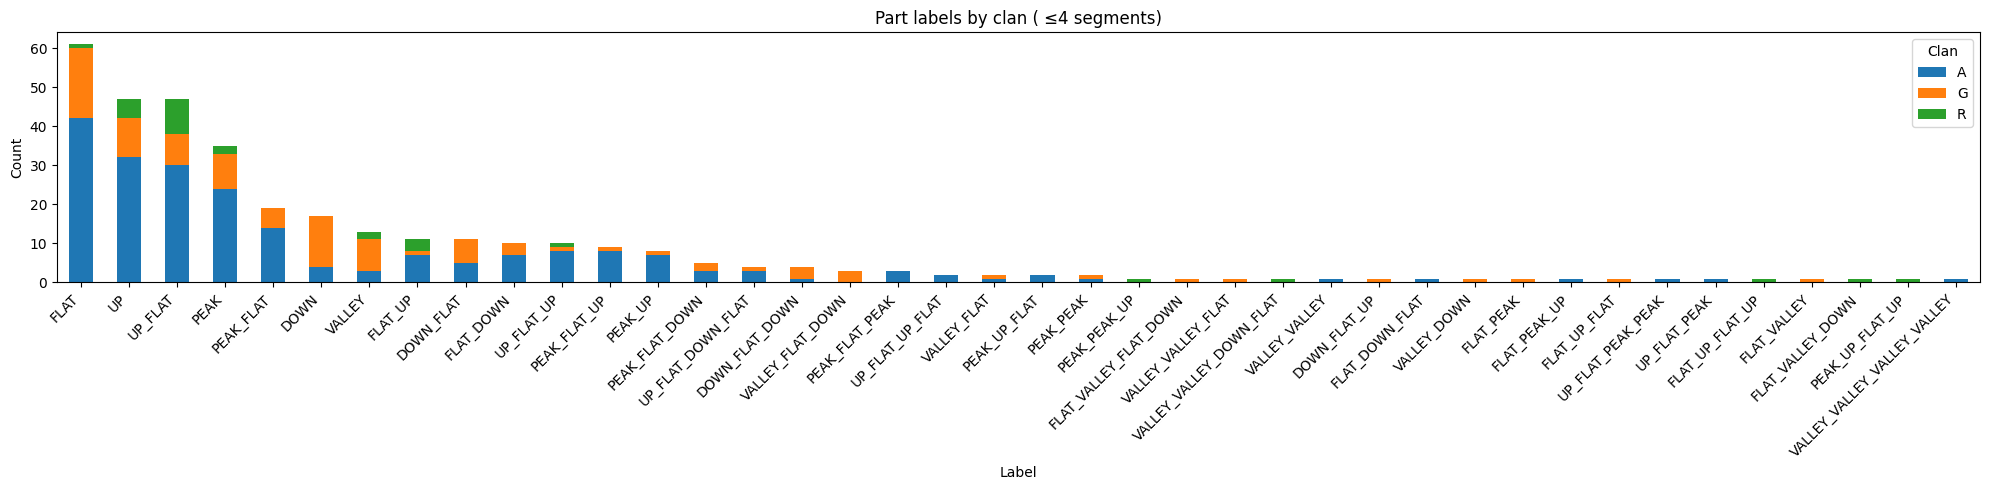

In [38]:
ct = p_df.groupby(["label", "clan"]).size().unstack(fill_value=0)
ct = ct.loc[ct.sum(axis=1).sort_values(ascending=False).index]

ct.plot.bar(stacked=True, figsize=(max(len(ct) * 0.5, 8), 5))
plt.ylabel("Count")
plt.xlabel("Label")
plt.title("Part labels by clan ( ≤4 segments)")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Clan")
plt.tight_layout()
plt.show()

## 7. Frequency Analysis

### 7a. Mean frequency per call (violin)

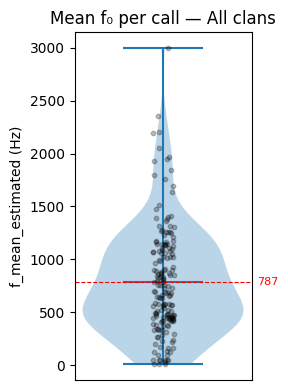

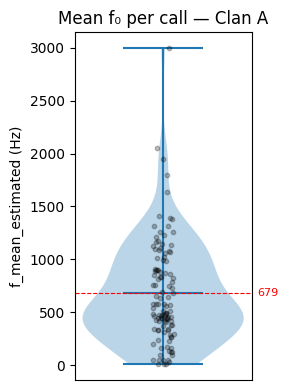

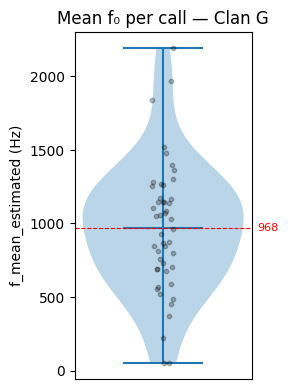

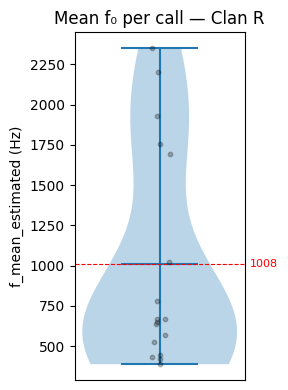

In [16]:
def plot_mean_violin(df, f_col="f_mean_estimated", group_col="filename", title=None):
    """Violin plot of mean `f_col` per group."""
    means = (
        df.sort_values([group_col, "t_start"])
        .groupby(group_col)[f_col]
        .mean()
        .dropna()
    )
    fig, ax = plt.subplots(figsize=(3, 4))
    ax.violinplot(means, showmeans=True, showmedians=False, widths=0.6)
    x_jitter = 1 + 0.08 * (np.random.rand(len(means)) - 0.5)
    ax.scatter(x_jitter, means, alpha=0.25, s=10, color="black", zorder=3)
    mean_val = means.mean()
    ax.axhline(mean_val, color="red", ls="--", lw=0.8)
    ax.text(1.35, mean_val, f"{mean_val:.0f}", va="center", color="red", fontsize=8)
    ax.set_ylabel(f"{f_col} (Hz)")
    ax.set_xticks([])
    ax.set_title(title or f"Mean {f_col} per call")
    plt.tight_layout()
    plt.show()

for clan in [None, "A", "G", "R"]:
    subset = parts_df if clan is None else parts_df[parts_df["clan"] == clan]
    label = "All clans" if clan is None else f"Clan {clan}"
    plot_mean_violin(subset, title=f"Mean f₀ per call — {label}")

### 7b. Start vs. end frequency per call

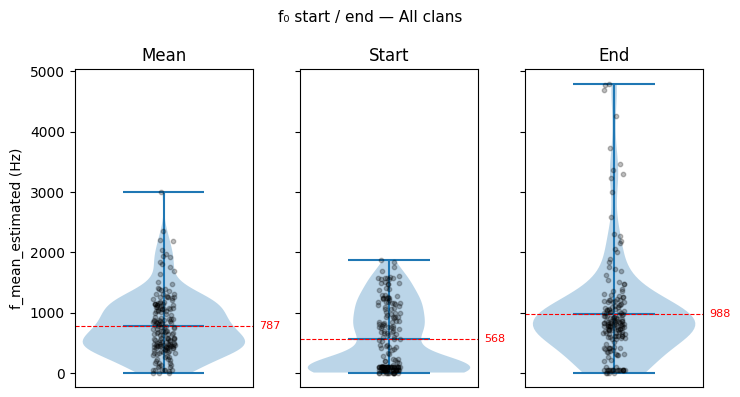

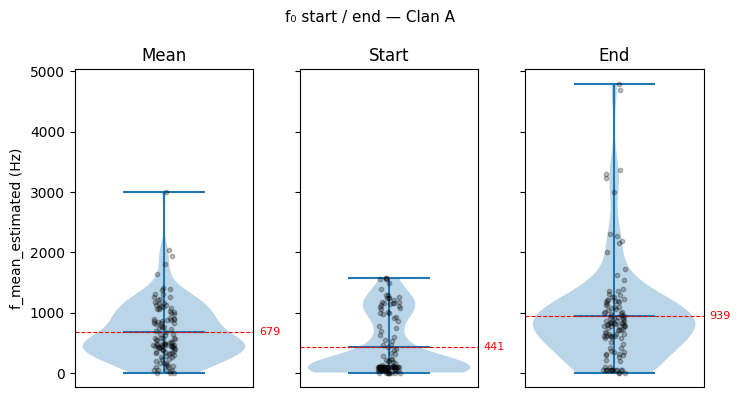

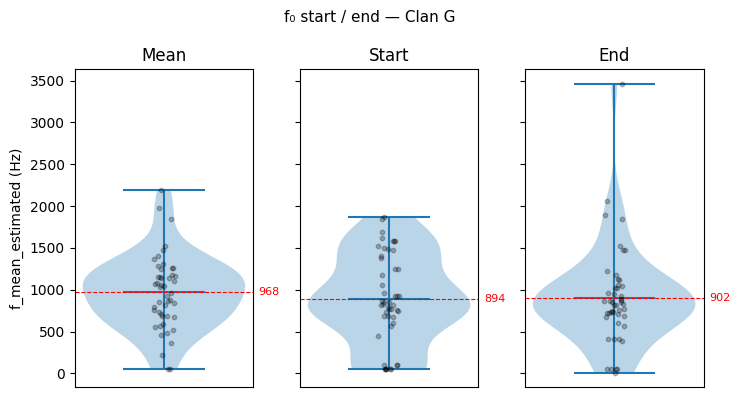

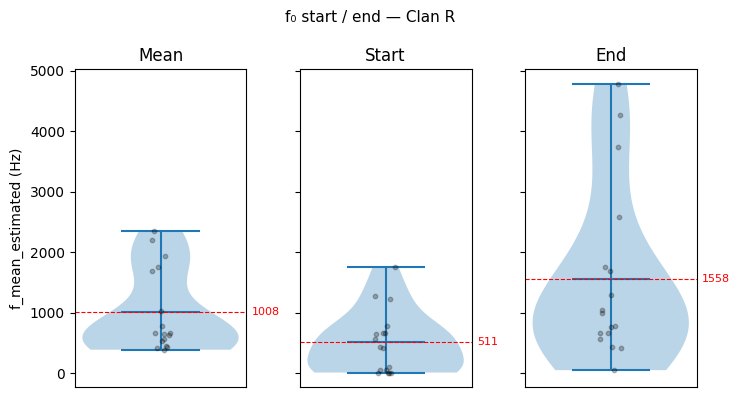

In [17]:
def plot_start_end_violin(df, f_col="f_mean_estimated", group_col="filename",
                          show_mean=True, title=None):
    """Side-by-side violin plots of the mean, first, and last `f_col` per group."""
    agg = (
        df.sort_values([group_col, "t_start"])
        .groupby(group_col)[f_col]
        .agg(["mean", "first", "last"])
        .dropna()
    )
    series = ([agg["mean"]] if show_mean else []) + [agg["first"], agg["last"]]
    labels = (["Mean"] if show_mean else []) + ["Start", "End"]

    fig, axes = plt.subplots(1, len(series), figsize=(2.5 * len(series), 4), sharey=True)
    for ax, data, lbl in zip(axes, series, labels):
        ax.violinplot(data, showmeans=True, showmedians=False, widths=0.6)
        x_jitter = 1 + 0.08 * (np.random.rand(len(data)) - 0.5)
        ax.scatter(x_jitter, data, alpha=0.25, s=10, color="black", zorder=3)
        mean_val = data.mean()
        ax.axhline(mean_val, color="red", ls="--", lw=0.8)
        ax.text(1.35, mean_val, f"{mean_val:.0f}", va="center", color="red", fontsize=8)
        ax.set_title(lbl)
        ax.set_xticks([])
    axes[0].set_ylabel(f"{f_col} (Hz)")
    fig.suptitle(title or f"Mean / Start / End {f_col}", fontsize=11)
    plt.tight_layout()
    plt.show()

for clan in [None, "A", "G", "R"]:
    subset = parts_df if clan is None else parts_df[parts_df["clan"] == clan]
    label = "All clans" if clan is None else f"Clan {clan}"
    plot_start_end_violin(subset, title=f"f₀ start / end — {label}")

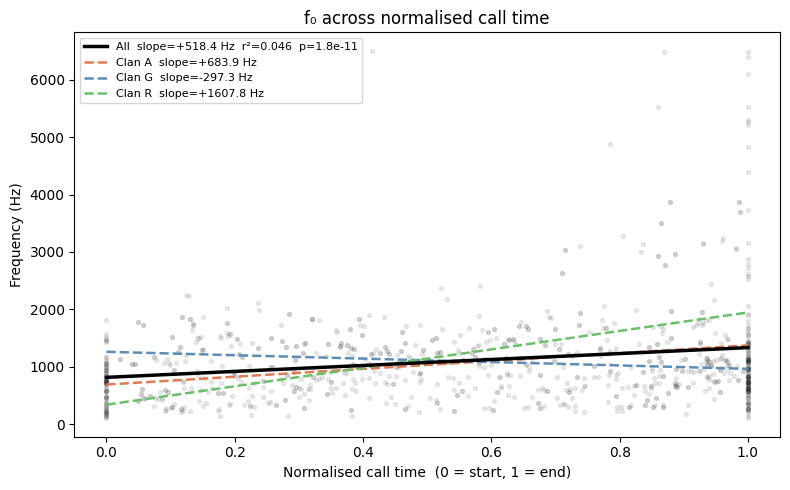

In [53]:
from scipy import stats

def _add_norm_time(df):
    g = df.groupby("filename")
    t_min = g["t_start"].transform("min")
    t_max = g["t_end"].transform("max")
    dur = t_max - t_min
    df = df.copy()
    df["t_start_norm"] = (df["t_start"] - t_min) / dur
    df["t_end_norm"]   = (df["t_end"]   - t_min) / dur
    return df

sn = _add_norm_time(segs_df)

pts = pd.concat([
    sn[["t_start_norm", "f_start", "filename", "clan"]].rename(columns={"t_start_norm": "t", "f_start": "f"}),
    sn[["t_end_norm",   "f_end",   "filename", "clan"]].rename(columns={"t_end_norm":   "t", "f_end":   "f"}),
], ignore_index=True).dropna()

# ── plot ───────────────────────────────────────────────────────────────────────
CLAN_COLORS = {"A": "#e07b54", "G": "#5b8db8", "R": "#6abf69"}
show_per_clan = True   # ← toggle

fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(pts["t"], pts["f"], alpha=0.08, s=8, color="black", zorder=1)

x = np.array([0.0, 1.0])

# overall OLS
slope, intercept, r, p, _ = stats.linregress(pts["t"], pts["f"])
ax.plot(x, intercept + slope * x, color="black", lw=2.5,
        label=f"All  slope={slope:+.1f} Hz  r²={r**2:.3f}  p={p:.2g}", zorder=3)

# per-clan OLS
if show_per_clan:
    for clan, grp in pts.groupby("clan"):
        if len(grp) < 10:
            continue
        s, i, r, p, _ = stats.linregress(grp["t"], grp["f"])
        color = CLAN_COLORS.get(clan, "grey")
        ax.plot(x, i + s * x, color=color, lw=1.8, ls="--",
                label=f"Clan {clan}  slope={s:+.1f} Hz ", zorder=2)
                # label=f"Clan {clan}  slope={s:+.1f} Hz  r²={r**2:.3f}  p={p:.2g}", zorder=2)

ax.set_xlabel("Normalised call time  (0 = start, 1 = end)")
ax.set_ylabel("Frequency (Hz)")
ax.set_title("f₀ across normalised call time")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


### 7c. Inter-part frequency ratio

For consecutive precise parts within a call: does f₀ shift up or down between parts?

/var/folders/j5/prvccmy93sn3187zg4qcc1_40000gn/T/ipykernel_3677/3018553953.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.DataFrame({
/var/folders/j5/prvccmy93sn3187zg4qcc1_40000gn/T/ipykernel_3677/3018553953.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


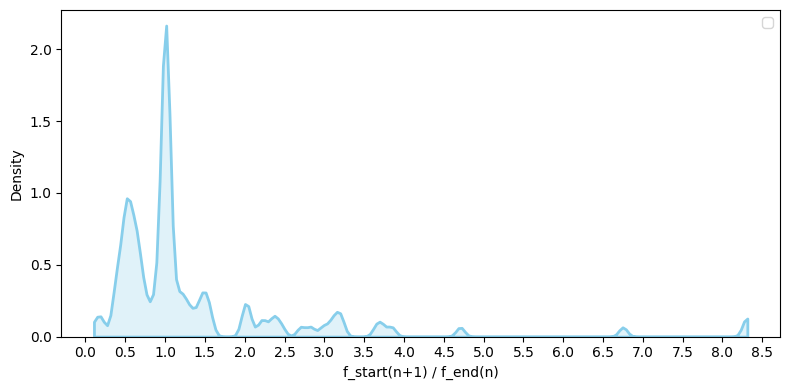

In [85]:
precise_df = parts_df[parts_df["part_type"] == "precise"].copy()

inter_part = (
    precise_df.sort_values(["filename", "t_start"])
    .groupby("filename")
    .apply(lambda g: pd.DataFrame({
        "f_end_prev": g["f_end"].values[:-1],
        "f_start_next": g["f_start"].values[1:],
        "clan": g["clan"].values[:-1],
    }))
    .reset_index(drop=True)
)
inter_part["ratio"] = inter_part["f_start_next"] / inter_part["f_end_prev"]
inter_part = inter_part[inter_part["ratio"].notna()]

fig, ax = plt.subplots(figsize=(8, 4))
sns.kdeplot(
    inter_part["ratio"], ax=ax, fill=True, color="skyblue", linewidth=2,
    bw_adjust=0.1, clip=(inter_part["ratio"].min(), inter_part["ratio"].max())
)
# ax.axvline(1.0, color="red", ls="--", lw=1, label="ratio = 1 (no shift)")
ax.set_xlabel("f_start(n+1) / f_end(n)")
ax.set_ylabel("Density")
# ax.set_title("KDE of inter-part frequency ratio")
ax.xaxis.set_major_locator(plt.MultipleLocator(0.5))
ax.legend()
plt.tight_layout()
plt.show()

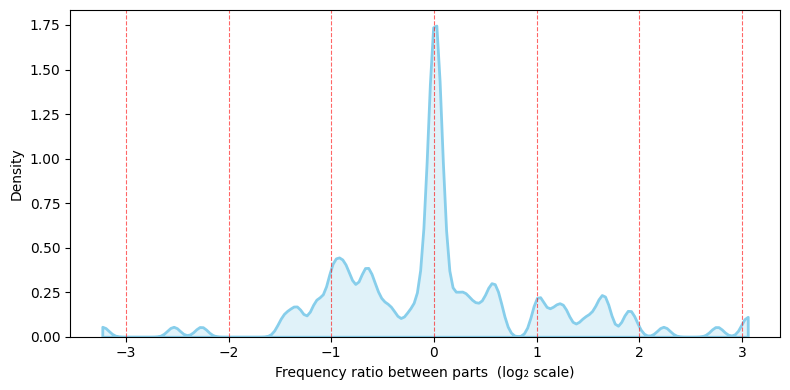

In [86]:
inter_part["log2_ratio"] = np.log2(inter_part["ratio"])

fig, ax = plt.subplots(figsize=(8, 4))
sns.kdeplot(
    inter_part["log2_ratio"], ax=ax, fill=True, color="skyblue", linewidth=2,
    bw_adjust=0.15,
    clip=(inter_part["log2_ratio"].min(), inter_part["log2_ratio"].max())
)

# mark octave positions
octave_ticks = np.arange(-3, 4, 1)
# octave_labels = ["−2 oct", "−1 oct\n(÷2)", "unison", "+1 oct\n(×2)", "+2 oct\n(×4)"]
for ov in octave_ticks:
    ax.axvline(ov, color="red", ls="--", lw=0.8, alpha=0.6)

ax.set_xticks(octave_ticks)
# ax.set_xticklabels(octave_labels, fontsize=8)
ax.set_xlabel("Frequency ratio between parts  (log₂ scale)")
ax.set_ylabel("Density")
plt.tight_layout()
plt.show()

In [101]:
epsilon = 0.01

nearest_octave = np.round(inter_part["log2_ratio"])
inter_part["close_to_different_octave"] = (
    (np.abs(inter_part["log2_ratio"] - nearest_octave) <= epsilon)
    & (nearest_octave != 0)
)

number_of_transitions = len(inter_part)
number_of_close_to_different_octave = len(inter_part[inter_part["close_to_different_octave"]])
print(f"Number of transitions: {number_of_transitions}")
print(f"Number of close to different octave: {number_of_close_to_different_octave}")
print(f"With epsilon={epsilon}, percentage: {number_of_close_to_different_octave / number_of_transitions * 100:.2f}%")

# ── binomial test ─────────────────────────────────────────────────────────────
from scipy import stats

log2_vals = inter_part["log2_ratio"].dropna()
lo, hi = log2_vals.min(), log2_vals.max()

# null: uniform over range, excluding the band around 0
integers_in_range = np.arange(np.ceil(lo), np.floor(hi) + 1, dtype=int)
non_zero_integers = integers_in_range[integers_in_range != 0]
null_p = len(non_zero_integers) * 2 * epsilon / (hi - lo)

result = stats.binomtest(
    number_of_close_to_different_octave,
    number_of_transitions,
    p=null_p,
    alternative="greater"
)

print(f"\nlog₂-ratio range: [{lo:.2f}, {hi:.2f}]")
print(f"Non-zero integers in range: {list(non_zero_integers)}")
print(f"Null probability (uniform, excl. 0): {null_p:.4f}  ({null_p*100:.2f}%)")
print(f"p-value: {result.pvalue:.4g}")


Number of transitions: 119
Number of close to different octave: 6
With epsilon=0.01, percentage: 5.04%

log₂-ratio range: [-3.23, 3.06]
Non-zero integers in range: [np.int64(-3), np.int64(-2), np.int64(-1), np.int64(1), np.int64(2), np.int64(3)]
Null probability (uniform, excl. 0): 0.0191  (1.91%)
p-value: 0.02715


In [109]:
from scipy import stats

epsilon = 0.01

rows = []
log2_vals = inter_part["log2_ratio"].dropna()
lo, hi = log2_vals.min(), log2_vals.max()
span = hi - lo

integers_in_range = np.arange(np.ceil(lo), np.floor(hi) + 1, dtype=int)
non_zero_integers = integers_in_range[integers_in_range != 0]

for octave in non_zero_integers:
    mask = (np.abs(inter_part["log2_ratio"] - octave) <= epsilon)
    count = mask.sum()
    null_p = 2 * epsilon / span   # one integer's band
    result = stats.binomtest(count, number_of_transitions, p=null_p, alternative="greater")
    rows.append({
        "octave": int(octave),
        "count": count,
        "pct": count / number_of_transitions * 100,
        "null_pct": null_p * 100,
        "p_raw": result.pvalue,
        "p_bonferroni": min(result.pvalue * len(non_zero_integers), 1.0),
    })

octave_table = pd.DataFrame(rows).set_index("octave")
octave_table["significant"] = octave_table["p_bonferroni"] < 0.05
print(octave_table.to_string(float_format="{:.4f}".format))


        count    pct  null_pct  p_raw  p_bonferroni  significant
octave                                                          
-3          0 0.0000    0.3183 1.0000        1.0000        False
-2          0 0.0000    0.3183 1.0000        1.0000        False
-1          4 3.3613    0.3183 0.0006        0.0037         True
 1          2 1.6807    0.3183 0.0557        0.3341        False
 2          0 0.0000    0.3183 1.0000        1.0000        False
 3          0 0.0000    0.3183 1.0000        1.0000        False


In [93]:
from scipy import stats

log2_vals = inter_part["log2_ratio"].dropna()
lo, hi = log2_vals.min(), log2_vals.max()

# Under H0 (uniform): probability of landing within epsilon of any integer
integers_in_range = np.arange(np.ceil(lo), np.floor(hi) + 1, dtype=int)
null_p = len(integers_in_range) * 2 * epsilon / (hi - lo)

result = stats.binomtest(
    number_of_close_to_octave,
    number_of_transitions,
    p=null_p,
    alternative="greater"   # one-sided: more octave-aligned than chance
)

print(f"log₂-ratio range: [{lo:.2f}, {hi:.2f}]")
print(f"Integers in range: {list(integers_in_range)}")
print(f"Null probability (uniform): {null_p:.4f}  ({null_p*100:.2f}%)")
print(f"Observed:  {number_of_close_to_octave}/{number_of_transitions}  ({number_of_close_to_octave/number_of_transitions*100:.2f}%)")
print(f"p-value: {result.pvalue:.4g}")


log₂-ratio range: [-3.23, 3.06]
Integers in range: [np.int64(-3), np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
Null probability (uniform): 0.0223  (2.23%)
Observed:  22/119  (18.49%)
p-value: 2.884e-14


In [ ]:

inter_part["down_1_octave"] = np.isclose(inter_part["log2_ratio"], -1, atol=epsilon)


print(len(inter_part))
print(len(inter_part[inter_part["down_1_octave"]]))
inter_part[inter_part["down_1_octave"]]

119
19


,f_end_prev,f_start_next,clan,ratio,log2_ratio,down_1_octave
2,1528.1761,769.0400,A,0.503240,-0.990680,True
15,1232.4589,622.2540,A,0.504888,-0.985964,True
20,1826.8867,917.7885,A,0.502378,-0.993154,True
26,1200.5255,734.2308,A,0.611591,-0.709361,True
50,1704.4644,926.6041,A,0.543634,-0.879293,True
52,1985.5802,1037.4843,A,0.522509,-0.936471,True
53,1652.0193,953.0785,A,0.576917,-0.793564,True
58,626.3611,340.8929,A,0.544243,-0.877676,True
60,447.9137,223.9568,A,0.500000,-1.000000,True
80,1844.3154,818.1584,A,0.443611,-1.172633,True


In [78]:
inter_part[inter_part["log2_ratio"].isna()]

,f_end_prev,f_start_next,clan,ratio,log2_ratio,down_1_octave
6,NaN,1554.5239,A,NaN,NaN,False
14,368.8701,NaN,A,NaN,NaN,False
23,1268.7120,NaN,A,NaN,NaN,False
27,1192.5940,NaN,A,NaN,NaN,False
28,1323.7201,NaN,A,NaN,NaN,False
29,1252.7223,NaN,A,NaN,NaN,False
30,NaN,1088.3627,A,NaN,NaN,False
31,NaN,789.5603,A,NaN,NaN,False
32,708.0083,NaN,A,NaN,NaN,False
33,NaN,1114.8371,A,NaN,NaN,False


### 7d. Consecutive f₀ scatter (transition plot)

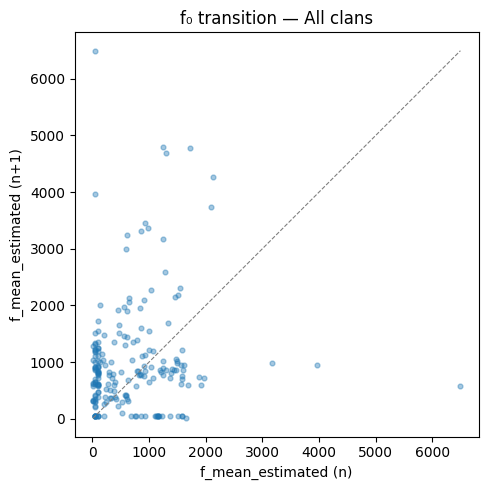

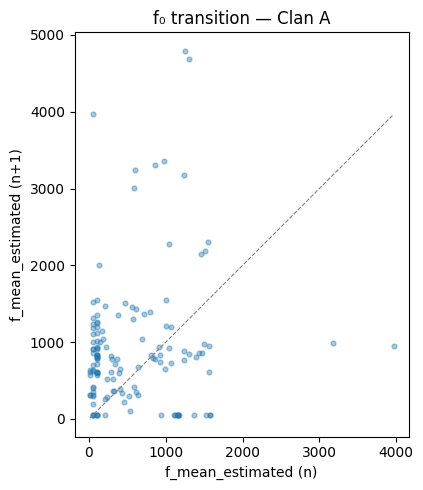

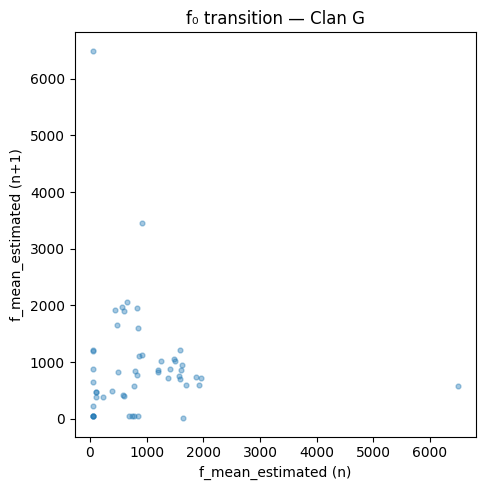

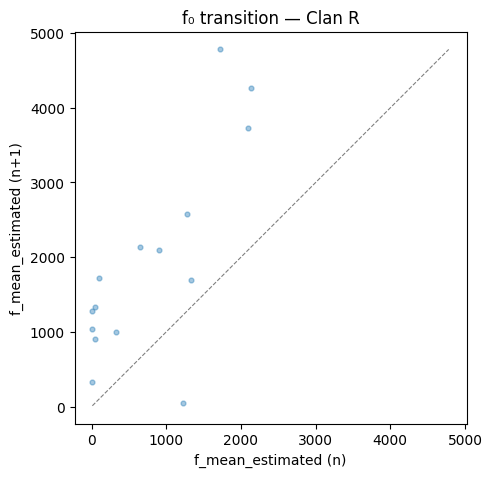

In [20]:
def plot_f_transition(df, f_col="f_mean", group_col="filename", ax=None, title=None, alpha=0.4, s=12):
    """Scatter of f(n) vs f(n+1) within each group."""
    prev_vals, next_vals = [], []
    for _, grp in df.groupby(group_col):
        vals = grp[f_col].values
        prev_vals.extend(vals[:-1])
        next_vals.extend(vals[1:])

    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 5))

    ax.scatter(prev_vals, next_vals, alpha=alpha, s=s)
    lo = min(min(prev_vals), min(next_vals))
    hi = max(max(prev_vals), max(next_vals))
    ax.plot([lo, hi], [lo, hi], ls="--", c="grey", lw=0.8)
    ax.set_xlabel(f"{f_col} (n)")
    ax.set_ylabel(f"{f_col} (n+1)")
    ax.set_title(title or f"Consecutive {f_col} transitions")
    ax.set_aspect("equal")
    return ax

for clan in [None, "A", "G", "R"]:
    subset = parts_df if clan is None else parts_df[parts_df["clan"] == clan]
    label = "All clans" if clan is None else f"Clan {clan}"
    fig, ax = plt.subplots(figsize=(5, 5))
    plot_f_transition(subset, f_col="f_mean_estimated", ax=ax, title=f"f₀ transition — {label}")
    plt.tight_layout()
    plt.show()

## 8. Transition Matrices

### 8a. Segment label transitions

In [21]:
def plot_transition_matrix(df, col="label", group_col="filename", label_order=None,
                           normalize=True, add_start_end=False, ax=None, cmap="Blues", title=None):
    """
    Transition probability (or count) matrix for consecutive values of `col` within each group.
    """
    pairs = []
    for _, grp in df.groupby(group_col):
        vals = list(grp[col].values)
        if add_start_end:
            vals = ["START"] + vals + ["END"]
        pairs.extend(zip(vals[:-1], vals[1:]))

    trans_df = pd.DataFrame(pairs, columns=["from", "to"])
    counts = trans_df.groupby(["from", "to"]).size().unstack(fill_value=0)

    observed = set(counts.index) | set(counts.columns)
    if label_order is not None:
        all_labels = [l for l in label_order if l in observed and l not in ("START", "END")]
    else:
        all_labels = sorted(observed - {"START", "END"})
    if add_start_end:
        all_labels = ["START"] + all_labels + ["END"]
    counts = counts.reindex(index=all_labels, columns=all_labels, fill_value=0)

    if normalize:
        matrix = counts.div(counts.sum(axis=1), axis=0).fillna(0)
        fmt, default_title = ".2f", f"Transition probabilities — {col}"
    else:
        matrix = counts
        fmt, default_title = "d", f"Transition counts — {col}"

    if ax is None:
        fig, ax = plt.subplots(figsize=(len(all_labels) * 1.1 + 1, len(all_labels) * 0.9 + 1))

    im = ax.imshow(matrix.values, cmap=cmap, aspect="auto", vmin=0, vmax=matrix.values.max() or 1)
    ax.set_xticks(range(len(all_labels)))
    ax.set_yticks(range(len(all_labels)))
    ax.set_xticklabels(all_labels, rotation=45, ha="right")
    ax.set_yticklabels(all_labels)
    ax.set_xlabel("To")
    ax.set_ylabel("From")
    ax.set_title(title or default_title)

    for i in range(len(all_labels)):
        for j in range(len(all_labels)):
            val = matrix.values[i, j]
            text = f"{val:{fmt}}"
            color = "white" if val > matrix.values.max() / 2 else "black"
            ax.text(j, i, text, ha="center", va="center", color=color, fontsize=9)

    plt.colorbar(im, ax=ax, shrink=0.8)
    plt.tight_layout()
    return matrix

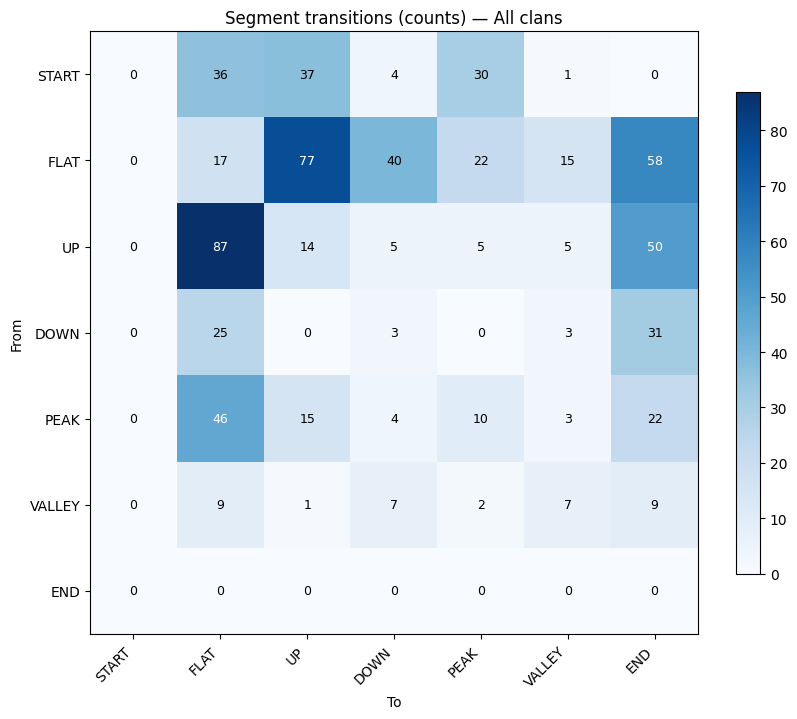

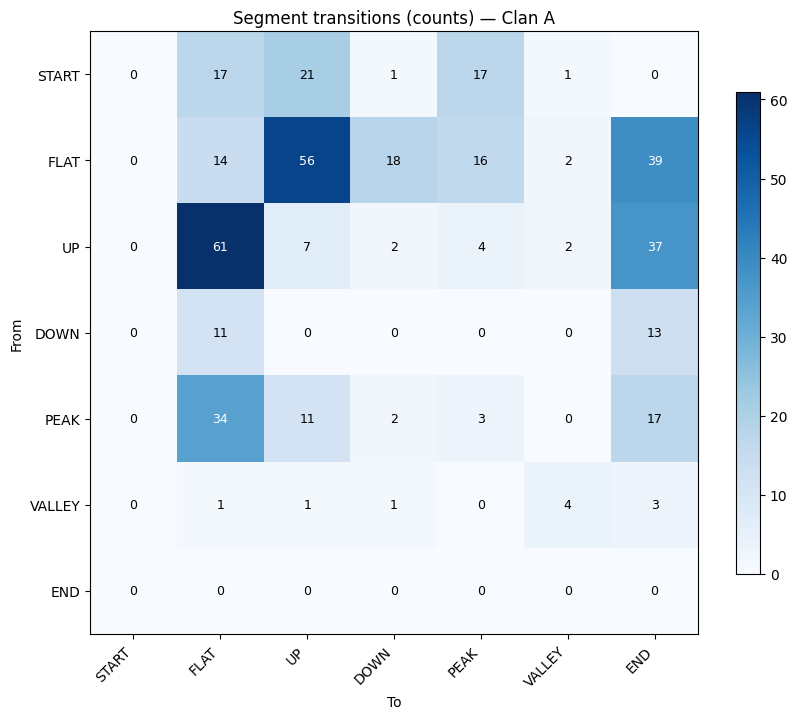

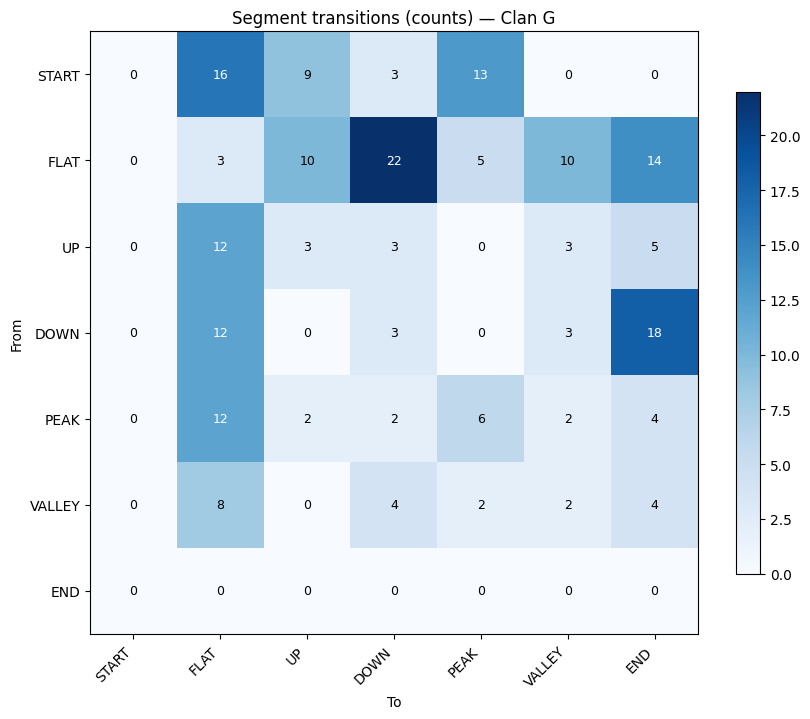

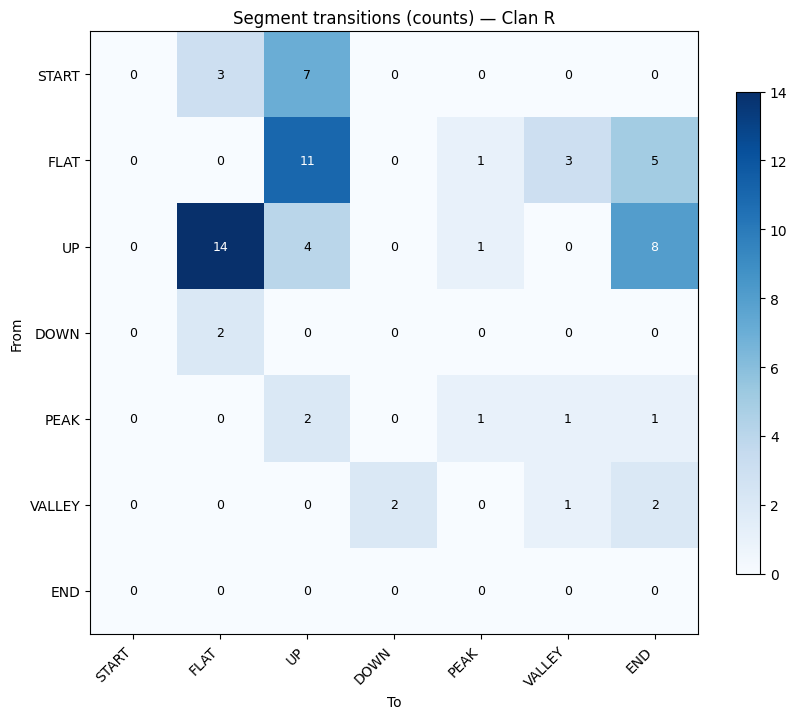

In [22]:
SEG_ORDER = ["FLAT", "UP", "DOWN", "PEAK", "VALLEY", "SQUIGGLE"]

for clan in [None, "A", "G", "R"]:
    subset = segs_df if clan is None else segs_df[segs_df["clan"] == clan]
    label = "All clans" if clan is None else f"Clan {clan}"
    plot_transition_matrix(
        subset, col="label", label_order=SEG_ORDER,
        normalize=False, add_start_end=True,
        title=f"Segment transitions (counts) — {label}"
    )
    plt.show()

### 8b. Frequency-band transitions

Bin each part by its estimated mean frequency and look at part-to-part frequency-band transitions.

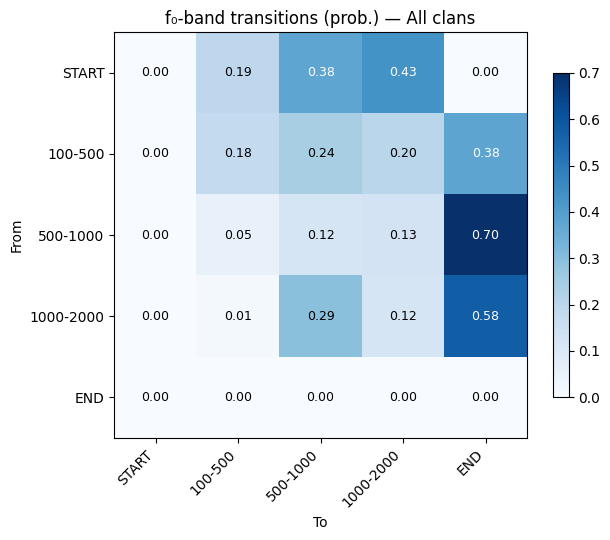

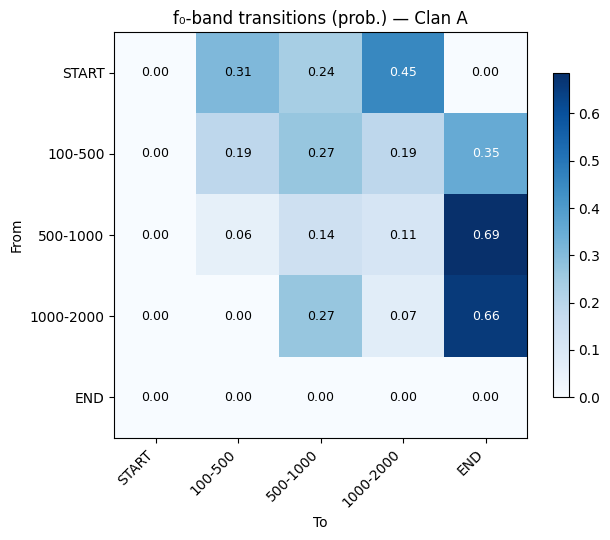

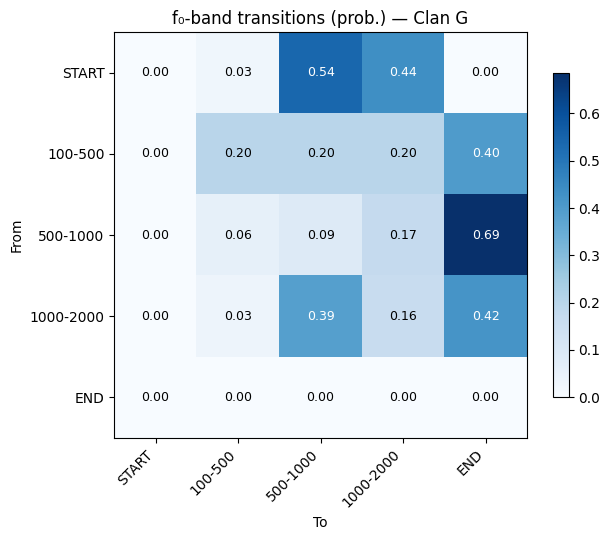

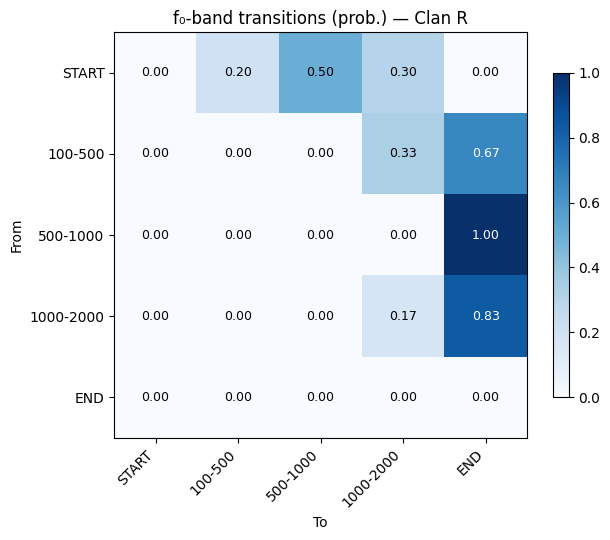

In [23]:
BIN_EDGES = [0, 100, 500, 1000, 2000]

def get_f0_bin(row, bin_edges, f_col="f_mean_estimated"):
    if f_col == "f_mean_estimated" and row["part_type"] != "precise":
        return row["part_type"]
    if pd.isnull(row[f_col]):
        return "nan"
    val = row[f_col]
    for i in range(len(bin_edges) - 1):
        if val < bin_edges[i + 1]:
            return f"{bin_edges[i]}-{bin_edges[i + 1]}"
    return f"{bin_edges[-1]}+"

parts_df["f0_binned"] = parts_df.apply(get_f0_bin, axis=1, bin_edges=BIN_EDGES)
NUMERIC_BINS = [f"{BIN_EDGES[i]}-{BIN_EDGES[i+1]}" for i in range(len(BIN_EDGES) - 1)]

for clan in [None, "A", "G", "R"]:
    subset = parts_df if clan is None else parts_df[parts_df["clan"] == clan]
    subset = subset[subset["f0_binned"] != "nan"]
    label = "All clans" if clan is None else f"Clan {clan}"
    plot_transition_matrix(
        subset, col="f0_binned", label_order=NUMERIC_BINS,
        normalize=True, add_start_end=True,
        title=f"f₀-band transitions (prob.) — {label}"
    )
    plt.show()

## 9. Sequence Similarity Analysis

### 9a. Within-call-type edit distance

How stereotyped is each call type? Lower normalised edit distance = more similar token sequences across exemplars.

In [24]:
sequences = (
    segs_df.sort_values(["filename", "t_start"])
    .groupby("filename")["label"]
    .apply(list)
)

rows = []
for call_type, group in calls_df.groupby("call_type"):
    filenames = group["filename"].values
    seqs = [sequences[f] for f in filenames if f in sequences.index]
    n = len(seqs)
    if n < 2:
        continue
    dists = [nltk.edit_distance(seqs[i], seqs[j]) for i, j in combinations(range(n), 2)]
    norm_dists = [
        nltk.edit_distance(seqs[i], seqs[j]) / max(len(seqs[i]), len(seqs[j]))
        for i, j in combinations(range(n), 2)
    ]
    rows.append({
        "call_type": call_type,
        "n_calls": n,
        "mean_edit_dist": np.mean(dists),
        "max_edit_dist": np.max(dists),
        "mean_norm_dist": np.mean(norm_dists),
    })

tightness_df = pd.DataFrame(rows).sort_values("mean_norm_dist")
tightness_df

,call_type,n_calls,mean_edit_dist,max_edit_dist,mean_norm_dist
32,N53,2,0.000000,0,0.000000
25,N43,2,0.000000,0,0.000000
21,N34,2,0.000000,0,0.000000
11,N20,2,0.000000,0,0.000000
27,N45,2,1.000000,1,0.333333
26,N44,3,2.000000,3,0.355556
5,N07,17,2.213235,6,0.453694
12,N23,10,2.222222,5,0.462963
31,N51,2,2.000000,2,0.500000
16,N28,2,2.000000,2,0.500000


### 9b. t-SNE of all calls

Embed every call in 2D using normalised pairwise edit distance, coloured by call type.

In [ ]:
def plot_call_tsne(calls_df, segs_df, color_by="call_type", perplexity=5, random_state=42):
    """t-SNE of all calls using normalised edit distance on token sequences."""
    sequences = (
        segs_df.sort_values(["filename", "t_start"])
        .groupby("filename")["label"]
        .apply(list)
    )
    valid = calls_df[calls_df["filename"].isin(sequences.index)].copy().reset_index(drop=True)
    filenames = valid["filename"].values
    seqs = [sequences[f] for f in filenames]
    n = len(seqs)

    dist_matrix = np.zeros((n, n))
    for i, j in combinations(range(n), 2):
        d = nltk.edit_distance(seqs[i], seqs[j]) / max(len(seqs[i]), len(seqs[j]))
        dist_matrix[i, j] = dist_matrix[j, i] = d

    perp = min(perplexity, n - 1)
    tsne = TSNE(n_components=2, metric="precomputed", perplexity=perp,
                random_state=random_state, init="random")
    coords = tsne.fit_transform(dist_matrix)

    color_labels = valid[color_by].values
    unique_labels = sorted(set(color_labels))
    cmap = cm.get_cmap("tab20", len(unique_labels))
    color_map = {lbl: cmap(i) for i, lbl in enumerate(unique_labels)}

    fig, ax = plt.subplots(figsize=(10, 7))
    for lbl in unique_labels:
        mask = color_labels == lbl
        ax.scatter(coords[mask, 0], coords[mask, 1],
                   label=lbl, color=color_map[lbl], s=80, alpha=0.85,
                   edgecolors="white", linewidths=0.5)
    for i, row in valid.iterrows():
        ax.annotate(row["call_type_variant"], (coords[i, 0], coords[i, 1]),
                    fontsize=7, alpha=0.7, textcoords="offset points", xytext=(4, 2))
    ax.legend(title=color_by, bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
    ax.set_title(f"t-SNE of calls (colored by {color_by})")
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    plt.tight_layout()
    plt.show()

plot_call_tsne(calls_df, segs_df, color_by="call_type")